# Examen 2

Nombre: **Nava Valencia Francisco Javier**

### Física Computacional 2025-2

Resuelva los siguientes ejercicios.

1. Utilice la biblioteca de ```scipy.special``` para realizar la gráfica de la función $\Gamma (x)$ en el intervalo (0,5]. Ajuste la imagen de la gráfica para que el eje vertical se encuentre en el intervalo $[0,5]$ y el eje horizontal en el dominio antes mencionado.

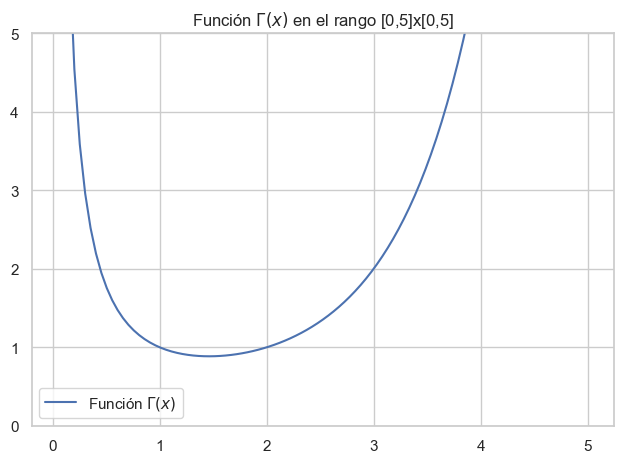

In [12]:
import scipy.special as sp
import numpy  as np
import seaborn as sns
import matplotlib.pyplot as plt

x = np.linspace(0,5,100)
y = sp.gamma(x)

sns.set_theme(style="whitegrid")

sns.lineplot(x=x,y=y,label=f"Función $\Gamma (x)$")
plt.title(f"Función $\Gamma(x)$ en el rango [0,5]x[0,5]")
plt.ylim(0,5)



plt.legend()
plt.tight_layout()
plt.show()

2. Se tiene la ecuación diferencial para $P(t)$

$$
\frac{dP}{dt} = rP \left( 1 - \frac{P}{P_c} \right)
$$

donde $r$ y $P_c$ son constantes positivas. Genere una función que se pueda utilizar para realizar una integración numérica de la ecuación diferencial y que además tenga como argumentos opcionales las dos constantes anteriores.

In [40]:
def dP(t, P, r=0.1, Pc=1000):
    """Ecuación diferencial: dP/dt = r*P*(1 - P/Pc)"""
    return r * P * (1 - P / Pc)

#Runge Kutta 4
def integrador_rk4(func,y0,t_start,t_end,steps,**kwargs):

    '''
    Implementación manual de Runge-Kutta
    y0: condición inicial
    steps. pasos
    **kwards: Constantes r y Pc
    '''
    h = (t_end - t_start)/steps #Tamaño del paso
    t = t_start
    y = y0
    #Liostas para guardar los resultados y poder graficarlos
    tiempos = [t]
    resultados = [y]

    for _ in range(steps):
        # Es vital que 'y' y 't' se pasen correctamente aquí
        k1 = func(t, y, **kwargs)
        k2 = func(t + h/2, y + h*k1/2, **kwargs)
        k3 = func(t + h/2, y + h*k2/2, **kwargs)
        k4 = func(t + h, y + h*k3, **kwargs)
        
        y = y + (h/6) * (k1 + 2*k2 + 2*k3 + k4)
        t = t + h
        
        tiempos.append(t)
        resultados.append(y)

    return tiempos, resultados


#Parametros 
poblacion_inicial = 10     # P0 (muy pequeña)
tiempo_final = 100          # ¡Asegúrate de que este tiempo sea largo!
capacidad_carga = 500       # Pc

# Ejecutar integración
t_vals, p_vals = integrador_rk4(
    dP, 
    poblacion_inicial, 
    0, 
    tiempo_final, 
    200, # Más pasos para suavizar la gráfica
    r=0.25, # Una tasa de crecimiento decente
    Pc=capacidad_carga
)

print(f"Tiempo final: {t_vals[-1]:.2f} | Población final: {p_vals[-1]:.2f}")

Tiempo final: 100.00 | Población final: 500.00


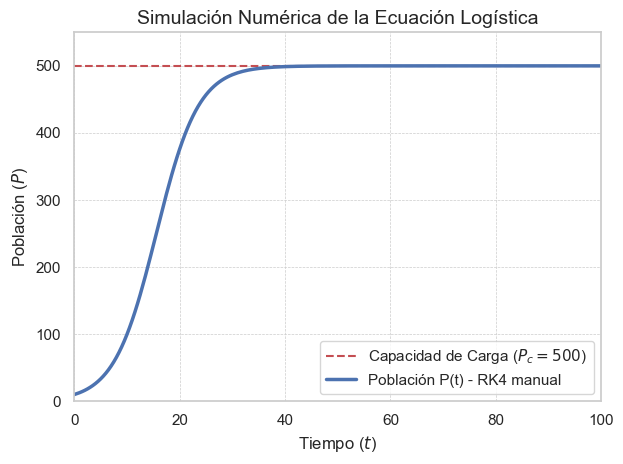

In [ ]:
plt.Figure(figsize=(10,6))
sns.set_theme(style="whitegrid")


plt.axhline(y=capacidad_carga, color='r', linestyle='--', linewidth=1.5, label=f'Capacidad de Carga ($P_c={capacidad_carga}$)')
sns.lineplot(x = t_vals, y = p_vals,color= 'b', linewidth=2.5, label='Población P(t) - RK4 manual')

plt.title('Simulación Numérica de la Ecuación Logística', fontsize=14)
plt.xlabel('Tiempo ($t$)', fontsize=12)
plt.ylabel('Población ($P$)', fontsize=12)
plt.xlim(0, tiempo_final)
plt.ylim(0, capacidad_carga * 1.1) # Un poco más arriba de Pc para ver la asíntota
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()

3. Utilice la función [solve_ivp](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html) de scipy para encontrar la solución numérica de la ecuación anterior para $r=0.5$, $P_c = 10$ y las condiciones iniciales $P(0) = \{1,3,5, ... 19 \}$. Elija un intervalo de integración donde se vea la tendencia de cada una de las soluciones y ponga todas las soluciones en una sola gráfica.

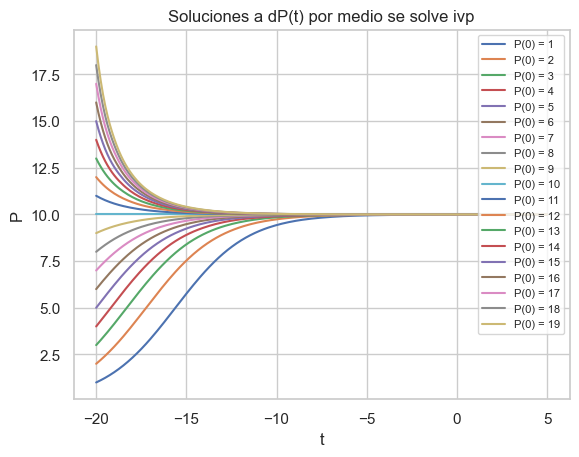

In [71]:
from scipy.integrate import solve_ivp

t = np.linspace(-20,5,200)
P0 = np.linspace(1,19,19)
sns.set_theme(style='whitegrid')
for ci in P0:
    solv_ivp = solve_ivp(dP,(-20,5),[ci],dense_output=True,args=[0.5,10])
    sns.lineplot(x=t, y=solv_ivp.sol(t)[0],  #se grafica cada solucion correspodiente a cada condicion inicial
             label=f'P(0) = {int(ci)}'
             )

plt.xlabel('t')
plt.ylabel('P')
plt.title('Soluciones a dP(t) por medio se solve ivp')
plt.legend(fontsize="8",        #se ajusta el tamaño de la leyenda para que entre en la grafica
           loc ="upper right")
plt.grid(True)
plt.show()

4. Tome la solución con $P(0)=3$ del problema anterior. Encuentre la máxima diferencia dicha solución y la función
$$
P(t) = \frac{ 30e^{t/2} }{ 10+3(e^{t/2} -1)}
$$

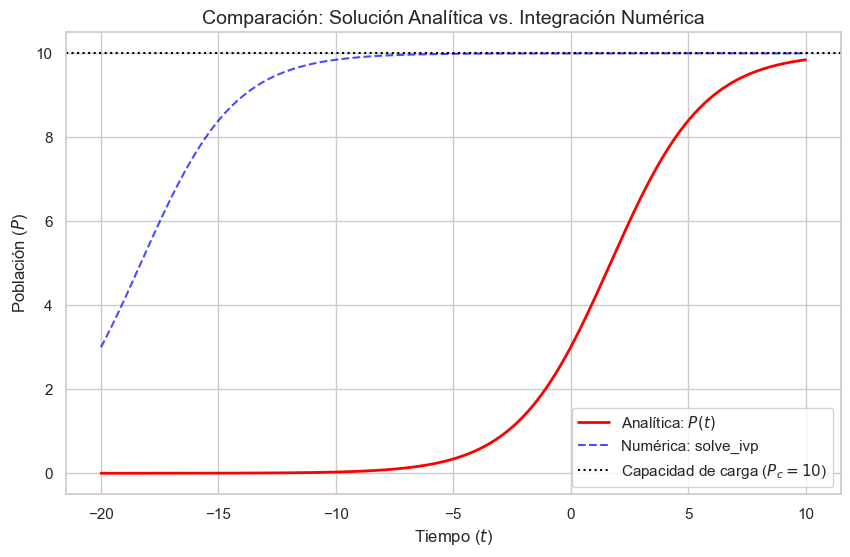

In [100]:
# Parámetros y condiciones
P0 = 3
r_val = 0.5
Pc_val = 10
t_rango = (-20, 10)

#analitica
def Pt(t):
    return (30 * np.exp(t / 2)) / (10 + 3 * (np.exp(t / 2) - 1))

#Solución Numérica con solve_ivp
solv_3 = solve_ivp(dP, t_rango, [P0], args=(r_val, Pc_val), dense_output=True)

#Preparación de datos para graficar
t_grafica = np.linspace(t_rango[0], t_rango[1], 300)
y_analitica = Pt(t_grafica)
y_numerica = solv_3.sol(t_grafica).T # Usamos el método .sol() gracias a dense_output

#Graficación
plt.figure(figsize=(10, 6))
sns.set_theme(style='whitegrid')

#Graficamos la analítica (Línea continua)
sns.lineplot(x=t_grafica, y=y_analitica, color='red', label='Analítica: $P(t)$', linewidth=2)

# Graficamos la numérica (Puntos o línea punteada para contrastar)
plt.plot(t_grafica, y_numerica, color='blue', linestyle='--', label='Numérica: solve_ivp', alpha=0.7)

# Detalles estéticos
plt.axhline(y=Pc_val, color='black', linestyle=':', label=f'Capacidad de carga ($P_c={Pc_val}$)')
plt.title('Comparación: Solución Analítica vs. Integración Numérica', fontsize=14)
plt.xlabel('Tiempo ($t$)')
plt.ylabel('Población ($P$)')
plt.legend()

plt.show()

In [104]:
# Asegúrate de que ambos tengan la misma forma (shape)
# y_numerica suele ser (1, 200), así que usamos .flatten() para que sea (200,)
error = np.abs(y_analitica - y_numerica.flatten())

# Diferencia promedio (MAE - Mean Absolute Error)
error_promedio = np.mean(error)
print(f"Error absoluto promedio: {error_promedio:.2e}")

Error absoluto promedio: 6.40e+00


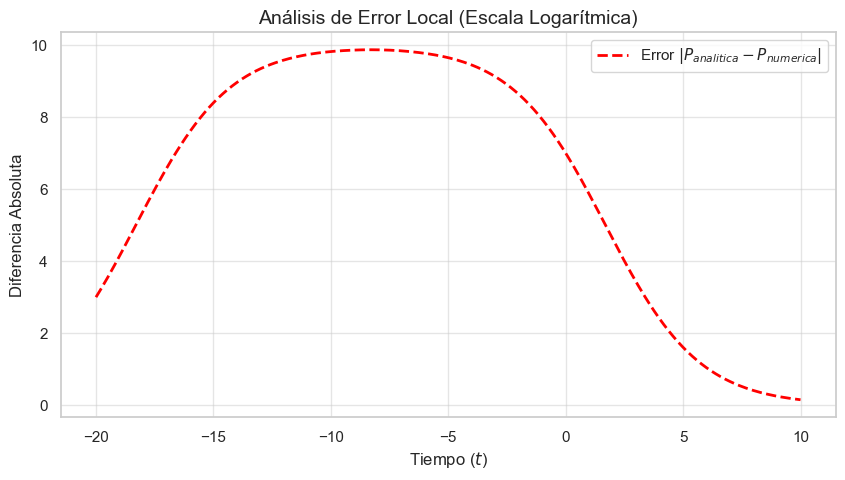

Error máximo detectado: 9.87e+00


In [116]:

# y_numerica suele venir de solve_ivp como (1, N), lo aplanamos a (N,)
y_num_flat = y_numerica.flatten()

error_absoluto = np.abs(y_analitica - y_num_flat)

plt.figure(figsize=(10, 5))
sns.set_theme(style='whitegrid')

plt.plot(t_grafica, error_absoluto, color='red', linestyle = '--',linewidth=2, label='Error $|P_{analitica} - P_{numerica}|$')

#plt.yscale('log')

# Estética y etiquetas
plt.title('Análisis de Error Local (Escala Logarítmica)', fontsize=14)
plt.xlabel('Tiempo ($t$)', fontsize=12)
plt.ylabel('Diferencia Absoluta', fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()

plt.show()

# Opcional: imprimir el error máximo encontrado
print(f"Error máximo detectado: {np.max(error_absoluto):.2e}")